# Market Mix Model: Where Should the Next Dollar Go?

We fit a `MarketMixPipeline` on synthetic weekly media + sales data, then use
the response curves to answer the question every CMO actually asks: **if I
shift $X from one channel to another, what happens to incremental sales?**

In [1]:
# Run once per session. In Colab, this installs into the runtime;
# in local Jupyter, it goes to the active kernel's environment.
import sys, subprocess
def _ensure(pkg, import_name=None):
    name = import_name or pkg.split('[')[0].split('==')[0]
    try:
        __import__(name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# In Colab/Jupyter, install ai2analytics from GitHub. If it's already
# installed locally (editable), this is a no-op.
try:
    import ai2analytics  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'git+https://github.com/jamesyoung93/AI2Analytics.git'])

# Plot helpers (matplotlib is already a hard dep of ai2analytics)
_ensure('matplotlib')
print('Setup complete.')

Setup complete.


## 1. Build a synthetic media + sales time-series

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n_weeks = 156  # 3 years
dates = pd.date_range('2023-01-06', periods=n_weeks, freq='W-FRI')

trend = np.linspace(100, 160, n_weeks)
seasonality = 25 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)

# Three media channels, very different cost & effectiveness profiles
tv      = rng.exponential(60, n_weeks).clip(0, 250)        # high reach, expensive
digital = rng.exponential(35, n_weeks).clip(0, 180)        # mid cost, mid effect
print_  = rng.exponential(25, n_weeks).clip(0, 120)        # cheap, low effect

# Sales DGP: log saturation per channel, true coefficients differ
sales = (trend + seasonality
         + 0.85 * np.log1p(tv)      * 12   # TV: strongest absolute effect
         + 0.55 * np.log1p(digital) * 9    # Digital: moderate
         + 0.25 * np.log1p(print_)  * 5    # Print: weakest
         + rng.normal(0, 8, n_weeks))

ts = pd.DataFrame({
    'WEEK_ENDING': dates,
    'SALES': sales.round(0),
    'TV_SPEND': tv.round(2),
    'DIGITAL_SPEND': digital.round(2),
    'PRINT_SPEND': print_.round(2),
    'PRICE_INDEX': (100 + rng.normal(0, 2, n_weeks)).round(1),
    'DISTRIBUTION_PCT': (85 + rng.normal(0, 3, n_weeks)).clip(70, 100).round(1),
})
ts.head()

,WEEK_ENDING,SALES,TV_SPEND,DIGITAL_SPEND,PRINT_SPEND,PRICE_INDEX,DISTRIBUTION_PCT
0,2023-01-06,177.0,144.25,12.75,29.88,97.2,81.2
1,2023-01-13,166.0,140.17,23.40,14.35,100.9,90.0
2,2023-01-20,186.0,143.09,85.29,15.00,98.4,90.2
3,2023-01-27,151.0,16.79,4.44,9.95,97.4,89.1
4,2023-02-03,149.0,5.19,6.68,29.17,101.4,85.8


## 2. Fit the model

In [3]:
from ai2analytics.templates.market_mix import MarketMixConfig, MarketMixPipeline

cfg = MarketMixConfig(
    analysis_name='brand_x_mmm',
    col_date='WEEK_ENDING',
    col_response='SALES',
    media_columns=['TV_SPEND', 'DIGITAL_SPEND', 'PRINT_SPEND'],
    control_columns=['PRICE_INDEX', 'DISTRIBUTION_PCT'],
    default_decay_rate=0.5,
    default_saturation='log',  # matches our DGP
    output_csv='mmm_brand_x.csv',
)

pipe = MarketMixPipeline()
out = pipe.run(cfg, dataframes={'time_series': ts})
out.channel_summary.round(3)


  PIPELINE: brand_x_mmm Market Mix Model

STAGE 1: Loading data
  Time series:   156 rows (in-memory)
  Date range:    2023-01-06 00:00:00 to 2025-12-26 00:00:00
  Periods:       156
  Media cols:    ['TV_SPEND', 'DIGITAL_SPEND', 'PRINT_SPEND']
  Control cols:  ['PRICE_INDEX', 'DISTRIBUTION_PCT']
  Done.

STAGE 2: Feature transformation
  Media: TV_SPEND -> decay=0.5, sat=log
  Media: DIGITAL_SPEND -> decay=0.5, sat=log
  Media: PRINT_SPEND -> decay=0.5, sat=log
  Control: PRICE_INDEX
  Control: DISTRIBUTION_PCT
  Structural: trend
  Structural: sin_52
  Structural: cos_52

  Features: 8
    Media:      3
    Control:    2
    Structural: 3
  Periods:  156
  Done.



STAGE 3: Model fitting
  Model: Ridge (alpha=1.0, positive=True)
  Intercept: 36.2002
  TV_SPEND_transformed: 14.826789
  DIGITAL_SPEND_transformed: 7.239968
  PRINT_SPEND_transformed: 1.507810
  PRICE_INDEX: 0.191486
  DISTRIBUTION_PCT: 0.000000
  trend: 53.152673
  sin_52: 24.443858
  cos_52: 0.000000

  R-squared:          0.8118
  Adjusted R-squared: 0.8015
  MAPE:               5.05%

  Contribution %:
    base: 19.60%
    TV_SPEND_transformed: 36.65%
    DIGITAL_SPEND_transformed: 15.81%
    PRINT_SPEND_transformed: 3.20%
    PRICE_INDEX: 10.35%
    DISTRIBUTION_PCT: 0.00%
    trend: 14.39%
    sin_52: 0.00%
    cos_52: 0.00%
  ROI TV_SPEND: 1.1937
  ROI DIGITAL_SPEND: 0.9076
  ROI PRINT_SPEND: 0.2095
  Done.

STAGE 4: Building output
  Contributions: 156 rows x 12 cols
  Channel summary: 6 channels
  R-squared: 0.8118, MAPE: 5.05%
  Response curves: 150 points
  Done.

STAGE 5: Writing output

  Channels: 6
    TV_SPEND: spend=8,847, contrib=10,560.83, ROI=1.1937
    DIGITAL_SPE

,channel,total_spend,total_contribution,contribution_pct,roi,coefficient,decay_rate
0,TV_SPEND,8846.87,10560.833,36.654,1.194,14.827,0.5
1,DIGITAL_SPEND,5017.53,4553.842,15.805,0.908,7.240,0.5
2,PRINT_SPEND,4399.19,921.469,3.198,0.209,1.508,0.5
3,base,0.00,5647.235,19.600,0.000,36.200,0.0
4,PRICE_INDEX,0.00,2982.713,10.352,0.000,0.191,0.0
5,DISTRIBUTION_PCT,0.00,0.000,0.000,0.000,0.000,0.0


## 3. Visual model fit

If the model can't reproduce the trajectory, ROI estimates are not trustworthy.

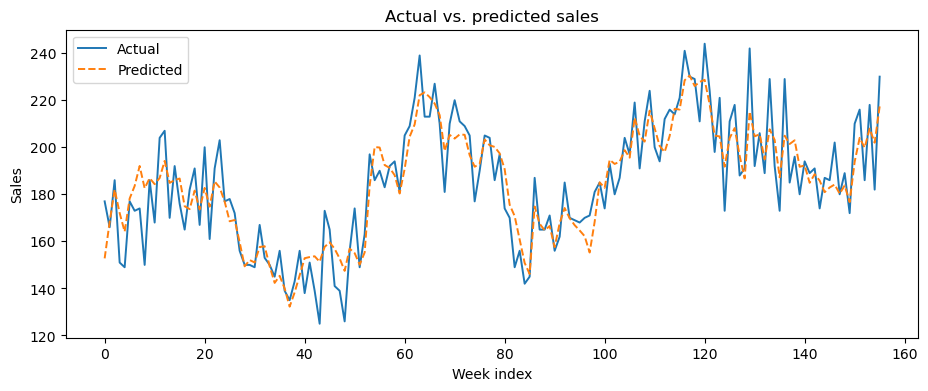

                          0
model_type            ridge
alpha                   1.0
r_squared            0.8118
adjusted_r_squared   0.8015
mape                 5.0496
n_periods               156
n_features                8
intercept           36.2002


In [4]:
import matplotlib.pyplot as plt

c = out.contributions
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(c['actual'].values, label='Actual', linewidth=1.4)
ax.plot(c['predicted'].values, label='Predicted', linewidth=1.4, linestyle='--')
ax.set_title('Actual vs. predicted sales')
ax.set_xlabel('Week index'); ax.set_ylabel('Sales')
ax.legend(); plt.show()
print(out.model_diagnostics.round(4).T)

## 4. The marginal-return curves (most important plot in MMM)

For each channel, plot incremental sales vs. spend after adstock + saturation.
The slope at your *current average spend* is roughly your marginal ROI.

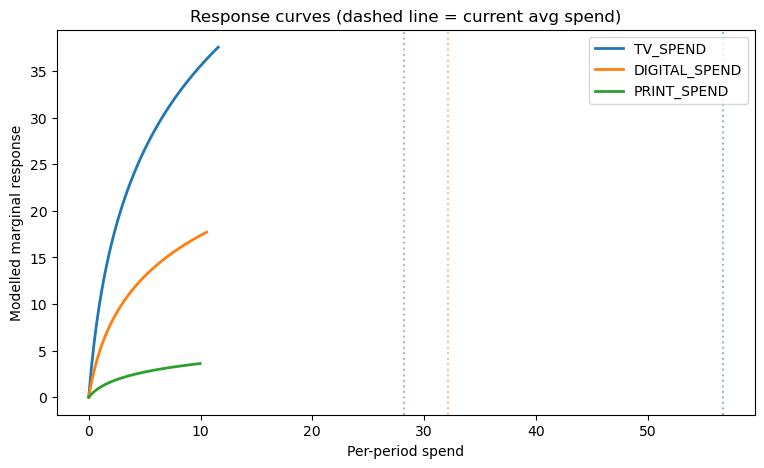

In [5]:
import matplotlib.pyplot as plt

rc = out.response_curves
mean_spend = ts[cfg.media_columns].mean()

fig, ax = plt.subplots(figsize=(9, 5))
for ch in cfg.media_columns:
    s = rc[rc['channel'] == ch]
    ax.plot(s['spend_level'], s['response'], linewidth=2, label=ch)
    ax.axvline(mean_spend[ch], linestyle=':', alpha=0.5,
               color=ax.lines[-1].get_color())
ax.set_xlabel('Per-period spend'); ax.set_ylabel('Modelled marginal response')
ax.set_title('Response curves (dashed line = current avg spend)')
ax.legend(); plt.show()

## 5. Budget what-if: where should the next $50 go?

Take a tiny grid of reallocation moves and pick the one that maximises predicted
sales while holding *total* media spend constant.

In [6]:
import numpy as np
import pandas as pd

def predicted_sales(weekly_alloc):
    """Estimate annualised sales lift for a given mean weekly spend per channel."""
    ann = 0.0
    coefs = out.channel_summary.set_index('channel')['coefficient']
    decay = out.channel_summary.set_index('channel')['decay_rate']
    for ch, spend in weekly_alloc.items():
        # Steady-state adstock multiplier = 1 / (1 - decay)
        ss = spend / max(1e-9, 1 - decay[ch])
        # Apply log saturation to match the DGP, then scale by coef
        ann += coefs[ch] * np.log1p(ss) * 52
    return ann

baseline = ts[cfg.media_columns].mean().to_dict()
base_pred = predicted_sales(baseline)
total_budget = sum(baseline.values())

# Search over allocations on a 5%-step simplex
results = []
for tv_pct in range(20, 81, 5):
    for digi_pct in range(10, 81 - tv_pct, 5):
        print_pct = 100 - tv_pct - digi_pct
        if print_pct < 5:
            continue
        alloc = {
            'TV_SPEND':      total_budget * tv_pct / 100,
            'DIGITAL_SPEND': total_budget * digi_pct / 100,
            'PRINT_SPEND':   total_budget * print_pct / 100,
        }
        results.append({
            'tv_%': tv_pct, 'digital_%': digi_pct, 'print_%': print_pct,
            'pred_ann_sales': predicted_sales(alloc),
        })
grid = pd.DataFrame(results)
best = grid.sort_values('pred_ann_sales', ascending=False).head(5)

current_mix = {
    'tv_%': round(baseline['TV_SPEND']      / total_budget * 100, 1),
    'digital_%': round(baseline['DIGITAL_SPEND'] / total_budget * 100, 1),
    'print_%': round(baseline['PRINT_SPEND']   / total_budget * 100, 1),
}
print('Current mix     :', current_mix, f'-> {base_pred:,.0f}')
print('\nTop 5 alloc moves:')
print(best.to_string(index=False))
print(f"\nBest move adds ~{best['pred_ann_sales'].iloc[0] - base_pred:,.0f} sales/yr at the same total spend.")

Current mix     : {'tv_%': 48.4, 'digital_%': 27.5, 'print_%': 24.1} -> 5,545

Top 5 alloc moves:
 tv_%  digital_%  print_%  pred_ann_sales
   55         25       20     5593.303321
   50         30       20     5587.998416
   60         20       20     5577.462097
   45         35       20     5564.770113
   50         25       25     5537.580956

Best move adds ~48 sales/yr at the same total spend.


## What this shows

- A modeller who fit the wrong saturation function would get wildly wrong
  marginal-ROI numbers. We deliberately picked `default_saturation='log'`
  because we know the DGP — in real life, you'd backtest several.
- The reallocation grid uses **only** quantities the pipeline already returns
  (`channel_summary` for coefficients/decay, `response_curves` for the shape).
  No bespoke math — just the model's learned structure applied to a what-if.
- This pattern (fit MMM → simulate budget moves) is the actionable handoff to
  the brand team. The pipeline gets you most of the way there in two cells.